Artifact directory ready: /content/artifacts/svm_5fold_cv

Loaded datasets:
Train: 1429
Validation: 306
Train+Validation: 1735
Test: 307

Class distribution:
Train: {0: 726, 1: 703}
Validation: {0: 155, 1: 151}
Train+Validation: {0: 881, 1: 854}
Test: {0: 156, 1: 151}

STARTING FOLD 1/5
Best row for this fold:
{'fold': 1, 'C': 1.0, 'val_accuracy': 0.9711815561959655, 'val_precision': 0.9819277108433735, 'val_recall': 0.9588235294117647, 'val_f1': 0.9702380952380952, 'val_roc_auc': np.float64(0.9958125623130607)}

STARTING FOLD 2/5
Best row for this fold:
{'fold': 2, 'C': 3.0, 'val_accuracy': 0.9769452449567724, 'val_precision': 0.9710982658959537, 'val_recall': 0.9824561403508771, 'val_f1': 0.9767441860465116, 'val_roc_auc': np.float64(0.997408293460925)}

STARTING FOLD 3/5
Best row for this fold:
{'fold': 3, 'C': 3.0, 'val_accuracy': 0.9654178674351584, 'val_precision': 0.9704142011834319, 'val_recall': 0.9590643274853801, 'val_f1': 0.9647058823529412, 'val_roc_auc': np.float64(0.9922

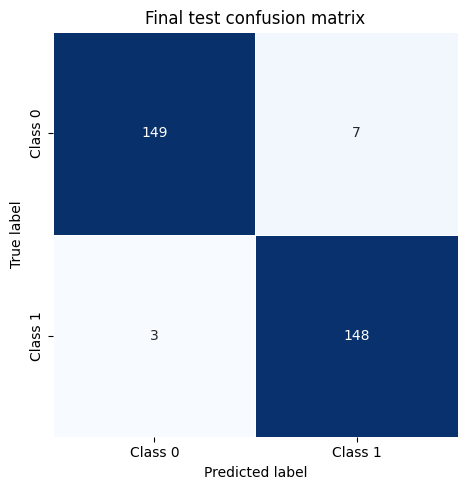

Final confusion matrix saved: /content/artifacts/svm_5fold_cv/final_test_confusion_matrix.png


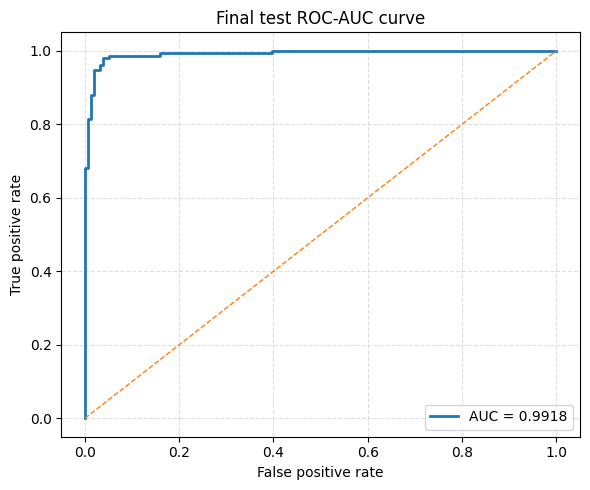

Final ROC curve saved: /content/artifacts/svm_5fold_cv/final_test_roc_curve.png

SVM 5-fold CV experiment finished successfully.
You now have:
- 5-fold CV fold results
- all CV tuning results
- CV summary statistics
- final trained model
- final vectorizer
- final test metrics JSON
- final classification report
- final test prediction CSV
- feature weights CSV
- final confusion matrix PNG
- final ROC curve PNG


In [ ]:
import os
import json
import pickle
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# =========================================================
# 0) SETTINGS
# =========================================================
RANDOM_SEED = 42

TRAIN_FILE = "/content/train.csv"
VAL_FILE = "/content/validation.csv"
TEST_FILE = "/content/test.csv"

TITLE_COL = "title"
TEXT_COL = "full_text"
LABEL_COL = "class_label"

MODEL_NAME = "svm_5fold_cv"
ARTIFACT_DIR = f"/content/artifacts/{MODEL_NAME}"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACT_DIR, "final_model.pkl")
VECTORIZER_PATH = os.path.join(ARTIFACT_DIR, "final_vectorizer.pkl")
CV_RESULTS_PATH = os.path.join(ARTIFACT_DIR, "cv_fold_results.csv")
CV_TUNING_PATH = os.path.join(ARTIFACT_DIR, "cv_all_tuning_results.csv")
CV_SUMMARY_PATH = os.path.join(ARTIFACT_DIR, "cv_summary_statistics.csv")
FINAL_METRICS_PATH = os.path.join(ARTIFACT_DIR, "final_test_metrics.json")
FINAL_REPORT_PATH = os.path.join(ARTIFACT_DIR, "final_test_classification_report.txt")
FINAL_PREDICTIONS_PATH = os.path.join(ARTIFACT_DIR, "final_test_predictions.csv")
FINAL_CONFUSION_MATRIX_PATH = os.path.join(ARTIFACT_DIR, "final_test_confusion_matrix.png")
FINAL_ROC_PATH = os.path.join(ARTIFACT_DIR, "final_test_roc_curve.png")
FEATURE_WEIGHTS_PATH = os.path.join(ARTIFACT_DIR, "final_feature_weights.csv")

C_GRID = [0.1, 0.3, 1.0, 3.0, 10.0]
N_FOLDS = 5

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Artifact directory ready:", ARTIFACT_DIR)

# =========================================================
# 1) HELPER FUNCTIONS
# =========================================================
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8")

    for col in [TITLE_COL, TEXT_COL, LABEL_COL]:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in file: {path}")

    df[TITLE_COL] = df[TITLE_COL].fillna("").astype(str)
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)

    return df


def make_text(df: pd.DataFrame):
    return (
        df[TITLE_COL].str.strip() + " " + df[TEXT_COL].str.strip()
    ).str.strip().tolist()


def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))


def get_prediction_group(true_label, pred_label):
    if true_label == 1 and pred_label == 1:
        return "TP"
    elif true_label == 0 and pred_label == 0:
        return "TN"
    elif true_label == 0 and pred_label == 1:
        return "FP"
    elif true_label == 1 and pred_label == 0:
        return "FN"
    return "UNKNOWN"


def evaluate_model(y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_score)
    report_text = classification_report(y_true, y_pred, digits=4, zero_division=0)

    metrics_dict = {
        "accuracy": float(acc),
        "precision": float(p),
        "recall": float(r),
        "f1_score": float(f1),
        "roc_auc": float(roc_auc)
    }

    metrics_df = pd.DataFrame({
        "metric": ["accuracy", "precision", "recall", "f1_score", "roc_auc"],
        "value": [acc, p, r, f1, roc_auc]
    })

    return metrics_dict, metrics_df, cm, report_text


def plot_confusion_matrix(cm, save_path):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"],
        cbar=False,
        square=True,
        linewidths=0.5
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Final test confusion matrix")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_roc_curve(y_true, y_score, roc_auc, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_score)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Final test ROC-AUC curve")
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def save_prediction_results(df_test, y_true, y_pred, y_prob, output_path):
    results_df = df_test[[TITLE_COL, TEXT_COL, LABEL_COL]].copy()
    results_df["pred_label"] = y_pred
    results_df["pred_prob"] = y_prob
    results_df["text_length"] = results_df[TEXT_COL].fillna("").astype(str).str.len()

    results_df["group"] = [
        get_prediction_group(true_label, pred_label)
        for true_label, pred_label in zip(y_true, y_pred)
    ]

    results_df = results_df[
        [
            TITLE_COL,
            TEXT_COL,
            LABEL_COL,
            "pred_label",
            "pred_prob",
            "group",
            "text_length"
        ]
    ]

    results_df.to_csv(output_path, index=False, encoding="utf-8")
    return results_df


# =========================================================
# 2) LOAD DATA
# =========================================================
train_df = load_df(TRAIN_FILE)
val_df = load_df(VAL_FILE)
test_df = load_df(TEST_FILE)

trainval_df = pd.concat([train_df, val_df], ignore_index=True)

print("\nLoaded datasets:")
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Train+Validation: {len(trainval_df)}")
print(f"Test: {len(test_df)}")

print("\nClass distribution:")
print("Train:", train_df[LABEL_COL].value_counts().to_dict())
print("Validation:", val_df[LABEL_COL].value_counts().to_dict())
print("Train+Validation:", trainval_df[LABEL_COL].value_counts().to_dict())
print("Test:", test_df[LABEL_COL].value_counts().to_dict())

X_trainval_text = make_text(trainval_df)
y_trainval = trainval_df[LABEL_COL].values

X_test_text = make_text(test_df)
y_test = test_df[LABEL_COL].values

# =========================================================
# 3) 5-FOLD CROSS-VALIDATION ON TRAIN+VALIDATION
# =========================================================
skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)

cv_fold_rows = []
cv_tuning_rows = []
best_C_per_fold = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval_text, y_trainval), start=1):
    print("\n" + "=" * 70)
    print(f"STARTING FOLD {fold_idx}/{N_FOLDS}")

    X_fold_train_text = [X_trainval_text[i] for i in train_idx]
    X_fold_val_text = [X_trainval_text[i] for i in val_idx]

    y_fold_train = y_trainval[train_idx]
    y_fold_val = y_trainval[val_idx]

    best_row = None

    for C in C_GRID:
        vectorizer = TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )

        X_fold_train = vectorizer.fit_transform(X_fold_train_text)
        X_fold_val = vectorizer.transform(X_fold_val_text)

        model = LinearSVC(
            C=C,
            class_weight="balanced",
            random_state=RANDOM_SEED
        )

        model.fit(X_fold_train, y_fold_train)

        val_pred = model.predict(X_fold_val)
        val_scores = model.decision_function(X_fold_val)

        acc = accuracy_score(y_fold_val, val_pred)
        p, r, f1, _ = precision_recall_fscore_support(
            y_fold_val,
            val_pred,
            average="binary",
            zero_division=0
        )
        roc_auc = roc_auc_score(y_fold_val, val_scores)

        row = {
            "fold": fold_idx,
            "C": C,
            "val_accuracy": acc,
            "val_precision": p,
            "val_recall": r,
            "val_f1": f1,
            "val_roc_auc": roc_auc
        }
        cv_tuning_rows.append(row)

        if best_row is None or row["val_f1"] > best_row["val_f1"]:
            best_row = row

    best_C = best_row["C"]
    best_C_per_fold.append(best_C)

    print("Best row for this fold:")
    print(best_row)

    # evaluate the best model for this fold again for fold-level summary
    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

    X_fold_train = vectorizer.fit_transform(X_fold_train_text)
    X_fold_val = vectorizer.transform(X_fold_val_text)

    model = LinearSVC(
        C=best_C,
        class_weight="balanced",
        random_state=RANDOM_SEED
    )

    model.fit(X_fold_train, y_fold_train)

    val_pred = model.predict(X_fold_val)
    val_scores = model.decision_function(X_fold_val)

    fold_metrics, _, _, _ = evaluate_model(
        y_true=y_fold_val,
        y_pred=val_pred,
        y_score=val_scores
    )

    fold_row = {
        "fold": fold_idx,
        "best_C": best_C,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        **fold_metrics
    }
    cv_fold_rows.append(fold_row)

# save CV tables
cv_results_df = pd.DataFrame(cv_fold_rows)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False, encoding="utf-8")

cv_tuning_df = pd.DataFrame(cv_tuning_rows)
cv_tuning_df.to_csv(CV_TUNING_PATH, index=False, encoding="utf-8")

cv_summary_df = pd.DataFrame([{
    "num_folds": N_FOLDS,
    "accuracy_mean": cv_results_df["accuracy"].mean(),
    "accuracy_std": cv_results_df["accuracy"].std(ddof=1),
    "precision_mean": cv_results_df["precision"].mean(),
    "precision_std": cv_results_df["precision"].std(ddof=1),
    "recall_mean": cv_results_df["recall"].mean(),
    "recall_std": cv_results_df["recall"].std(ddof=1),
    "f1_mean": cv_results_df["f1_score"].mean(),
    "f1_std": cv_results_df["f1_score"].std(ddof=1),
    "roc_auc_mean": cv_results_df["roc_auc"].mean(),
    "roc_auc_std": cv_results_df["roc_auc"].std(ddof=1)
}])
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False, encoding="utf-8")

print("\n=== 5-FOLD CV RESULTS ===")
print(cv_results_df.sort_values("f1_score", ascending=False).to_string(index=False))

print("\n=== 5-FOLD CV SUMMARY ===")
print(cv_summary_df.to_string(index=False))

# =========================================================
# 4) CHOOSE FINAL C FOR TRAINING ON ALL TRAIN+VALIDATION
# =========================================================
# izvēlamies C, kas visbiežāk bija labākais foldos
best_C_counts = pd.Series(best_C_per_fold).value_counts().sort_values(ascending=False)
final_C = float(best_C_counts.index[0])

print("\nBest C counts across folds:")
print(best_C_counts.to_string())

print(f"\nFinal chosen C for full train+validation training: {final_C}")

# =========================================================
# 5) FINAL TRAINING ON ALL TRAIN+VALIDATION
# =========================================================
final_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_trainval_final = final_vectorizer.fit_transform(X_trainval_text)
X_test_final = final_vectorizer.transform(X_test_text)

final_model = LinearSVC(
    C=final_C,
    class_weight="balanced",
    random_state=RANDOM_SEED
)

final_model.fit(X_trainval_final, y_trainval)

test_pred = final_model.predict(X_test_final)
test_scores = final_model.decision_function(X_test_final)
pred_prob = sigmoid(test_scores)

# =========================================================
# 6) FINAL TEST EVALUATION
# =========================================================
metrics_dict, metrics_df, cm, report_text = evaluate_model(
    y_true=y_test,
    y_pred=test_pred,
    y_score=test_scores
)

metrics_dict["final_C"] = final_C

print("\n=== FINAL TEST RESULTS ===")
print(metrics_df.to_string(index=False))

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(cm)

print("\nClassification report:")
print(report_text)

# =========================================================
# 7) SAVE FINAL MODEL + METRICS + REPORT
# =========================================================
with open(MODEL_PATH, "wb") as f:
    pickle.dump(final_model, f)

with open(VECTORIZER_PATH, "wb") as f:
    pickle.dump(final_vectorizer, f)

with open(FINAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=2)

with open(FINAL_REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report_text)

print("\nSaved final files:")
print(f"Model: {MODEL_PATH}")
print(f"Vectorizer: {VECTORIZER_PATH}")
print(f"Final metrics JSON: {FINAL_METRICS_PATH}")
print(f"Final classification report: {FINAL_REPORT_PATH}")

# =========================================================
# 8) SAVE FINAL PREDICTIONS
# =========================================================
results_df = save_prediction_results(
    df_test=test_df,
    y_true=y_test,
    y_pred=test_pred,
    y_prob=pred_prob,
    output_path=FINAL_PREDICTIONS_PATH
)

print(f"\nFinal prediction file saved: {FINAL_PREDICTIONS_PATH}")
print("\nPrediction file preview:")
print(results_df.head().to_string(index=False))

# =========================================================
# 9) SAVE FEATURE WEIGHTS
# =========================================================
feature_names = final_vectorizer.get_feature_names_out()
weights = final_model.coef_[0]

feature_weights_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights
}).sort_values("weight", ascending=False)

feature_weights_df.to_csv(FEATURE_WEIGHTS_PATH, index=False, encoding="utf-8")
print(f"\nFeature weights saved: {FEATURE_WEIGHTS_PATH}")

# =========================================================
# 10) PLOT + SAVE FINAL CONFUSION MATRIX
# =========================================================
plot_confusion_matrix(cm, FINAL_CONFUSION_MATRIX_PATH)
print(f"Final confusion matrix saved: {FINAL_CONFUSION_MATRIX_PATH}")

# =========================================================
# 11) PLOT + SAVE FINAL ROC CURVE
# =========================================================
plot_roc_curve(
    y_true=y_test,
    y_score=test_scores,
    roc_auc=metrics_dict["roc_auc"],
    save_path=FINAL_ROC_PATH
)
print(f"Final ROC curve saved: {FINAL_ROC_PATH}")

# =========================================================
# 12) FINAL MESSAGE
# =========================================================
print("\nSVM 5-fold CV experiment finished successfully.")
print("You now have:")
print("- 5-fold CV fold results")
print("- all CV tuning results")
print("- CV summary statistics")
print("- final trained model")
print("- final vectorizer")
print("- final test metrics JSON")
print("- final classification report")
print("- final test prediction CSV")
print("- feature weights CSV")
print("- final confusion matrix PNG")
print("- final ROC curve PNG")

In [ ]:
import pandas as pd
import plotly.express as px

PREDICTIONS_FILE = "//content/artifacts/svm_5fold_cv/final_test_predictions.csv"
SAVE_HTML = "/content/svm_prediction_confidence_by_group.html"
STATS_PATH = "/content/svm_prediction_confidence_by_group_stats.csv"

df = pd.read_csv(PREDICTIONS_FILE)

order = ["TP", "TN", "FP", "FN"]

# =========================
# PLOTLY BOXPLOT
# =========================
fig = px.box(
    df,
    x="group",
    y="pred_prob",
    category_orders={"group": order},
    title="SVM prediction confidence by outcome group",
    points="outliers",
    color_discrete_sequence=["#007BFF"]
)

fig.update_layout(
    xaxis_title="Outcome group",
    yaxis_title="Prediction confidence",
    template="plotly_white"
)

fig.write_html(SAVE_HTML)
fig.show()

# =========================
# STATISTIC
# =========================
summary = (
    df.groupby("group")["pred_prob"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        median="median",
        max="max"
    )
)

q1 = df.groupby("group")["pred_prob"].quantile(0.25)
q3 = df.groupby("group")["pred_prob"].quantile(0.75)

summary["q1"] = q1
summary["q3"] = q3
summary["iqr"] = summary["q3"] - summary["q1"]

summary = summary.reindex(order).reset_index()
summary.to_csv(STATS_PATH, index=False, encoding="utf-8")

print(summary.to_string(index=False))
print("\nSaved plot:", SAVE_HTML)
print("Saved stats:", STATS_PATH)

group  count     mean      std      min   median      max       q1       q3      iqr
   TP    148 0.683859 0.072102 0.513556 0.690562 0.848201 0.639907 0.731226 0.091318
   TN    149 0.337046 0.064431 0.185555 0.342098 0.499275 0.288137 0.380131 0.091994
   FP      7 0.564143 0.056282 0.508470 0.535470 0.652111 0.522753 0.603721 0.080968
   FN      3 0.423975 0.067945 0.360705 0.415431 0.495788 0.388068 0.455609 0.067541

Saved plot: /content/svm_prediction_confidence_by_group.html
Saved stats: /content/svm_prediction_confidence_by_group_stats.csv


In [ ]:
import shutil

source_folder = "/content/artifacts/svm_5fold_cv"
output_zip = "/content/svm_5fold_cv_results"

shutil.make_archive(output_zip, "zip", source_folder)

print("ZIP izveidots:", output_zip + ".zip")

ZIP izveidots: /content/svm_5fold_cv_results.zip


In [ ]:
import pandas as pd
import plotly.express as px

# =========================
# CONFIG
# =========================
TOP_N = 20
SAVE_HTML = "/content/top_feature_weights.html"

BLUE_CLASS_0 = "#007BFF"
ORANGE_CLASS_1 = "#FF7F0E"

# =========================
# EXTRACT FEATURE WEIGHTS
# =========================
feature_names = vectorizer.get_feature_names_out()
coefficients = model.coef_[0]

df_weights = pd.DataFrame({
    "feature": feature_names,
    "weight": coefficients
})

# Top features pushing toward class 0 (negative weights)
top_class_0 = (
    df_weights.sort_values("weight", ascending=True)
    .head(TOP_N)
    .copy()
)
top_class_0["class"] = "Class 0"

# Top features pushing toward class 1 (positive weights)
top_class_1 = (
    df_weights.sort_values("weight", ascending=False)
    .head(TOP_N)
    .copy()
)
top_class_1["class"] = "Class 1"

# Combine
plot_df = pd.concat([top_class_0, top_class_1], ignore_index=True)

# Sort for clean visualization
plot_df = plot_df.sort_values("weight", ascending=True)

# =========================
# PLOTLY BAR CHART
# =========================
fig = px.bar(
    plot_df,
    x="weight",
    y="feature",
    color="class",
    orientation="h",
    title=f"Top {TOP_N} Feature Weights by Class Direction",
    color_discrete_map={
        "Class 0": BLUE_CLASS_0,
        "Class 1": ORANGE_CLASS_1
    },
    hover_data={
        "feature": True,
        "weight": ":.4f",
        "class": True
    }
)

# Add vertical zero line
fig.add_vline(x=0, line_dash="dash", line_color="black")

fig.update_layout(
    template="plotly_white",
    xaxis_title="Feature Weight",
    yaxis_title="Feature",
    legend_title="Pulls toward",
    height=900
)

# Save + show
fig.write_html(SAVE_HTML)
fig.show()

print(f"Saved plot: {SAVE_HTML}")

Saved plot: /content/top_feature_weights.html


In [ ]:
fp_indices = df[df["group"] == "FP"].index.tolist()
fn_indices = df[df["group"] == "FN"].index.tolist()

print("FP indices:", fp_indices[:10])
print("FN indices:", fn_indices[:10])

print(f"\nTotal FP: {len(fp_indices)}")
print(f"Total FN: {len(fn_indices)}")


FP indices: [49, 76, 100, 143, 206, 248, 273]
FN indices: [38, 208, 264]

Total FP: 7
Total FN: 3


In [ ]:
# vispārliecinātākie FP
df[df["group"] == "FP"].sort_values("pred_prob", ascending=False).head(5)

# vissliktākie FN
df[df["group"] == "FN"].sort_values("pred_prob").head(5)

,title,full_text,class_label,pred_label,pred_prob,group,text_length
264,Šveicē aizliegta mamogrāfija?,EGOISTE VESELĪBA UN SKAISTUMS ⟩ Šveicē aizlieg...,1,0,0.360705,FN,925
38,"Nebūtu slikti, ja tā izskatītos Saturna zondes...",2017. gada 15. septembrī savā pēdējā misijā de...,1,0,0.415431,FN,1539
208,Baidena un Trampa debates: puspatiesības un kl...,Straujiem soļiem tuvojas 5. novembrī paredzētā...,1,0,0.495788,FN,1240
